In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

In [5]:
import os
print(os.getcwd())

/home/lakshya


In [6]:
df = pd.read_csv('/home/lakshya/jupyter/aml/class/college_dataset.csv')

In [10]:
df.head(), df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   student_id         2000 non-null   object 
 1   state              2000 non-null   object 
 2   category           2000 non-null   object 
 3   gender             2000 non-null   object 
 4   quota              312 non-null    object 
 5   12th_percentage    2000 non-null   float64
 6   entrance_score     2000 non-null   int64  
 7   effective_score    2000 non-null   int64  
 8   extracurriculars   2000 non-null   int64  
 9   preferences_count  2000 non-null   int64  
 10  assigned_college   2000 non-null   object 
 11  admission_chance   2000 non-null   float64
dtypes: float64(2), int64(4), object(6)
memory usage: 187.6+ KB


(  student_id          state category  gender quota  12th_percentage  \
 0      S0001      Karnataka      GEN    Male   NaN            80.96   
 1      S0002      Karnataka      OBC    Male   NaN            78.35   
 2      S0003    Maharashtra      OBC  Female   NaN            68.03   
 3      S0004  Uttar Pradesh      GEN    Male   NRI            43.65   
 4      S0005      Rajasthan      GEN    Male   TFW            64.10   
 
    entrance_score  effective_score  extracurriculars  preferences_count  \
 0             207              207                 2                  4   
 1             228              228                 1                  6   
 2             163              163                 1                  9   
 3             137               97                 2                  5   
 4             131              131                 2                  8   
 
                assigned_college  admission_chance  
 0         State Tech University             0.627  
 1

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [12]:
X = df[["12th_percentage", "entrance_score", "effective_score", "extracurriculars", "preferences_count"]]
y = df["admission_chance"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
y_pred = model.predict(X_test)

In [16]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [17]:
model.coef_, model.intercept_, mse, r2

(array([-0.00017425,  0.00068137,  0.00184536, -0.00028385,  0.00012936]),
 np.float64(0.10143868889491042),
 0.0017249164456044042,
 0.8508386533313477)

In [18]:
import matplotlib.pyplot as plt

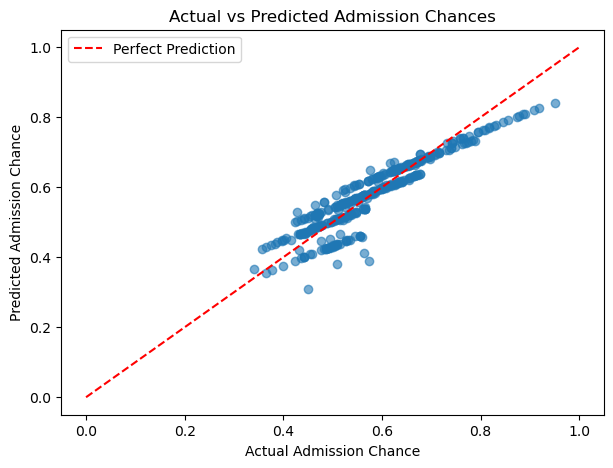

In [19]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Perfect Prediction")
plt.xlabel("Actual Admission Chance")
plt.ylabel("Predicted Admission Chance")
plt.title("Actual vs Predicted Admission Chances")
plt.legend()
plt.show()